# Trigger wave thresholds

In [1]:
import immunowave as iw
import numpy as np
import jax
import jax.numpy as jnp
import diffrax as dx

import matplotlib as mpl
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

## Model definition

Define the state and model for model 4 from the text.

In [2]:
class State4(iw.State):
    A: iw.ScalarField
    B: iw.ScalarField

In [3]:
class Model4(iw.Model):
    θ: float
    η: float
    ξ: float
    λ: float
    μ: float

    @jax.jit
    def __call__(self, t, state, args=None):
        # unpack field variables
        A, B = state.A, state.B
        # unpack parameters
        θ, η, ξ, λ, μ = self.θ, self.η, self.ξ, self.λ, self.μ
        # define PDE
        dAdt = A.laplacian(bc="neumann") + A * (A - θ) * (1 - A) + η * B
        dBdt = ξ * B.laplacian(bc="neumann") + λ * B * (1 - B) - μ * A * B
        return State4(dAdt, dBdt)

Instantiate model

In [4]:
model = Model4(θ=0.1, η=1.0, ξ=0.0, λ=0.0, μ=1.0)
model

Model4(θ=0.1, η=1.0, ξ=0.0, λ=0.0, μ=1.0)

## Immune response outcomes

Define immune response outcome in terms of the value of the $A$ field.
- If mean response $\frac{1}{L}\int_0^{L}A\left(x, t\right)\mathrm{d}x > 0.9$, then a tissue-scale response has been triggered at time $t$.
- If the mean response is small $\frac{1}{L}\int_0^{L}A\left(x, t\right)\mathrm{d}x < \frac{\theta}{2}$ while it is shrinking $\frac{\mathrm{d}}{\mathrm{d}t}\int_0^{L}A\left(x, t\right)\mathrm{d}x < 0$, then a transient response has subsided.

In [5]:
outcomes = ["inconclusive", "triggered", "transient"]


@jax.jit
def outcome(state, t, model):
    A_integral = state.A.integral()
    triggered = A_integral / L > 0.9
    low_activation = A_integral / L < model.θ / 10
    shrinking_activation = model(t, state).A.integral() < 0

    return jnp.where(
        triggered,
        1,
        jnp.where(
            jax.lax.bitwise_and(low_activation, shrinking_activation),
            2,
            0,
        ),
    )

## Solve

We set the upper bound of the integration region to infinity, and then terminate integration only when we encounter one of the two immune response events: tissue-scale triggering, or a transient response.

In [6]:
t0 = 0.0
t1 = jnp.inf

kwargs = dict(dt0=1e-4, max_steps=10000000, atol=1e-3, rtol=1e-3)

Instantiate state

In [7]:
L = 20.0
n = 200

shape = (n,)
lb = [0]
h = L / (n - 1)

In [8]:
state = State4(
    A=iw.ScalarField(shape, lb, h, 0),
    B=iw.ScalarField(
        shape, lb, h, fn=lambda x: 0.5 * jnp.exp(-((x - L / 2) ** 2) / (2 * 0.1**2))
    ),
)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Solve

In [9]:
solution = iw.solve(
    model,
    state,
    t0,
    t1,
    **kwargs,
    discrete_terminating_event=dx.DiscreteTerminatingEvent(
        lambda solver_state, **kwargs: outcome(
            solver_state.y, solver_state.tprev, model
        )
    ),
)

ValueError: `where` requires a scalar boolean predicate

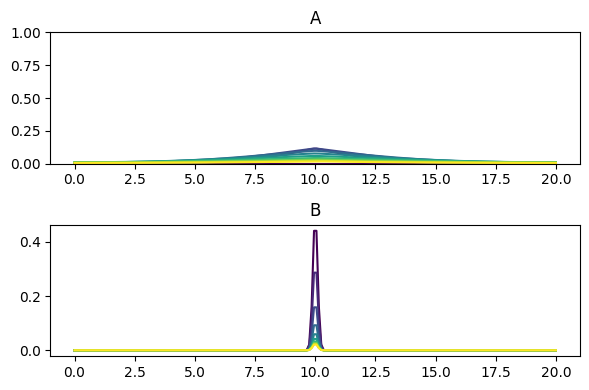

In [10]:
ts = solution.interpolation.ts[solution.interpolation.ts < np.inf]

cmap = plt.cm.ScalarMappable(
    norm=mpl.colors.Normalize(vmin=ts[0], vmax=ts[-1]), cmap=plt.cm.viridis
)

axes = None
for ti in np.linspace(ts[0], ts[-1], 10):
    axes = solution.evaluate(ti).plot(axes=axes, color=cmap.to_rgba(ti))
axes[0].set_ylim(0, max(1, solution.evaluate(ti).A.values.max()))
plt.show()

Integration was terminated at this time

In [11]:
ts[-1]

Array(45.1673, dtype=float64, weak_type=True)

The termination event was

In [12]:
outcomes[outcome(solution.evaluate(ts[-1]), ts[-1], model)]

'transient'

## Solve with a stronger bacterial stimulus

In [13]:
state = State4(
    A=iw.ScalarField(shape, lb, h, 0),
    B=iw.ScalarField(
        shape, lb, h, fn=lambda x: 10 * jnp.exp(-((x - L / 2) ** 2) / (2 * 0.1**2))
    ),
)

In [14]:
solution = iw.solve(
    model,
    state,
    t0,
    t1,
    **kwargs,
    discrete_terminating_event=dx.DiscreteTerminatingEvent(
        lambda solver_state, **kwargs: outcome(
            solver_state.y, solver_state.tprev, model
        )
    ),
)

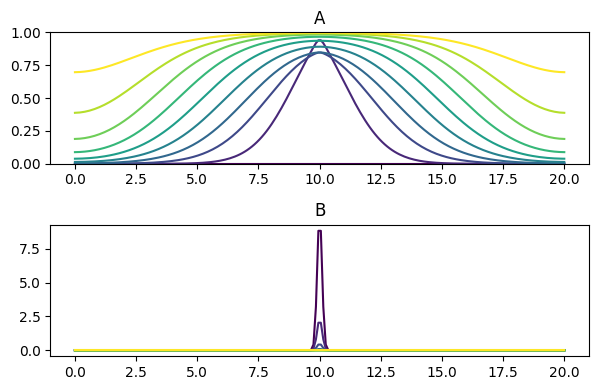

In [15]:
ts = solution.interpolation.ts[solution.interpolation.ts < np.inf]

cmap = plt.cm.ScalarMappable(
    norm=mpl.colors.Normalize(vmin=ts[0], vmax=ts[-1]), cmap=plt.cm.viridis
)

axes = None
for ti in np.linspace(ts[0], ts[-1], 10):
    axes = solution.evaluate(ti).plot(axes=axes, color=cmap.to_rgba(ti))
axes[0].set_ylim(0, max(1, solution.evaluate(ti).A.values.max()))
plt.show()

In [16]:
ts[-1]

Array(15.9785, dtype=float64, weak_type=True)

In [17]:
outcomes[outcome(solution.evaluate(ts[-1]), ts[-1], model)]

'triggered'

## Trigger thresholds

A function that takes $B_0$ and $\theta$, and returns the final response outcome (at the time the integration was terminated by an event).

In [18]:
@jax.jit
def response(B0, θ):
    model = Model4(θ=θ, η=1.0, ξ=0.0, λ=0.0, μ=1.0)
    state = State4(
        A=iw.ScalarField(shape, lb, h, 0),
        B=iw.ScalarField(
            shape, lb, h, fn=lambda x: B0 * jax.scipy.stats.norm.pdf(x, loc=L / 2, scale=0.1)
        ),
    )
    solution = iw.solve(
        model,
        state,
        t0,
        t1,
        **kwargs,
        discrete_terminating_event=dx.DiscreteTerminatingEvent(
            lambda solver_state, **kwargs: outcome(
                solver_state.y, solver_state.tprev, model
            )
        ),
    )
    t_final = jax.numpy.nanmax(jnp.where(jnp.isinf(solution.interpolation.ts), jnp.nan, solution.interpolation.ts))
    return outcome(solution.evaluate(t_final), t_final, model)
    # return solution.evaluate(t_final).A.integral() / L
    

I tried to do this with vmap, but the kernel kept crashing, so we'll simply loop

In [19]:
# response_vmap = jax.vmap(response, in_axes=(0, None))

In [27]:
θs = np.geomspace(0.01, 0.5, 10)
B0s = np.geomspace(0.01, 10.0, 10)

response_dat = np.zeros((len(θs), len(B0s)), dtype=int)
for i, θ in enumerate(θs):
    print(f"{θ=:.2f}")
    for j, B0 in enumerate(B0s):
        response_dat[i, j] = response(B0, θ)
        print(f"  {B0=:.2f}, {outcomes[response_dat[i, j]]}")

θ=0.01
  B0=0.01, triggered
  B0=0.02, triggered
  B0=0.05, triggered
  B0=0.10, triggered
  B0=0.22, triggered
  B0=0.46, triggered
  B0=1.00, triggered
  B0=2.15, triggered
  B0=4.64, triggered
  B0=10.00, triggered
θ=0.02
  B0=0.01, triggered
  B0=0.02, triggered
  B0=0.05, triggered
  B0=0.10, triggered
  B0=0.22, triggered
  B0=0.46, triggered
  B0=1.00, triggered
  B0=2.15, triggered
  B0=4.64, triggered
  B0=10.00, triggered
θ=0.02
  B0=0.01, transient
  B0=0.02, triggered
  B0=0.05, triggered
  B0=0.10, triggered
  B0=0.22, triggered
  B0=0.46, triggered
  B0=1.00, triggered
  B0=2.15, triggered
  B0=4.64, triggered
  B0=10.00, triggered
θ=0.04
  B0=0.01, transient
  B0=0.02, transient
  B0=0.05, triggered
  B0=0.10, triggered
  B0=0.22, triggered
  B0=0.46, triggered
  B0=1.00, triggered
  B0=2.15, triggered
  B0=4.64, triggered
  B0=10.00, triggered
θ=0.06
  B0=0.01, transient
  B0=0.02, transient
  B0=0.05, transient
  B0=0.10, triggered
  B0=0.22, triggered
  B0=0.46, trigg

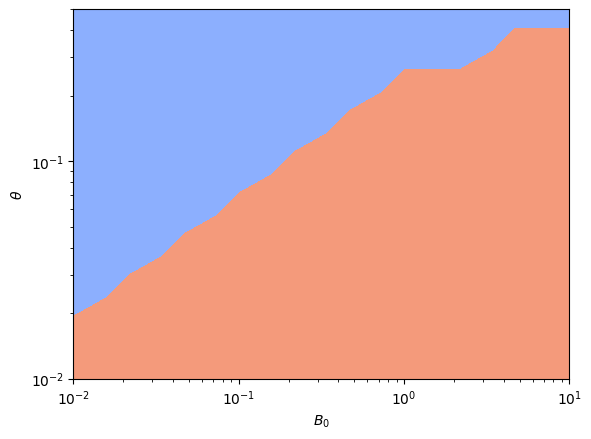

In [40]:
ax = plt.contourf(B0s, θs, response_dat, levels=1, cmap="coolwarm_r")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$B_0$")
plt.ylabel(r"$\theta$")
plt.show()

In [ ]:
0.